In [1]:
import numpy as np
import matplotlib.pyplot as plt

from field_lines import PeriodicInterpolator, integrate_lines, unwrap_lines, plot_field_lines
from generate_goldreich_sridhar import get_aniso_cube
from cubes import set_r_cube, set_k_cube

## Field generation

In [2]:
L = 300  # [pc], half-size
n_side = 256
dx = 2*L/n_side # [pc], cell size
k_min = 2*np.pi / (2*L)  # [pc-1], injection scale
print(f"Each cell is a cube with size dx = {dx:.2f} pc")
print(f"Injection scale (2pi/k_min) is {2*np.pi/k_min:.2f} pc")

r_cube = set_r_cube(n_side, L)
k_cube = set_k_cube(n_side, L)

Each cell is a cube with size dx = 2.34 pc
Injection scale (2pi/k_min) is 600.00 pc


In [3]:
b_cube = get_aniso_cube(n_side, L, k_min, model='YL02')

### Add the regular component

$$ \mathbf{B} = \dfrac{\mathbf{B}_0 + \eta\,\mathbf{\delta B}}{\sqrt{1 + \eta^2}} = \dfrac{1}{\sqrt{1 + \eta^2}}\mathbf{B}_0 + \dfrac{\eta}{\sqrt{1 + \eta^2}}\mathbf{\delta B}, $$

In [4]:
eta = 1.0

b0 = 1 / np.sqrt(1 + eta**2)

b_turb = eta / np.sqrt(1 + eta**2) * b_cube

b_cube_10 = b_turb
b_cube_10[..., 2] += b0

### Check the spectrum (Fourier transform)

In [5]:
b_cube_k = np.fft.rfftn(b_cube_10, norm='forward')

In [6]:
bk2 = np.sum(np.abs(b_cube_k)**2, axis=-1)
k_norm = np.sum(k_cube**2, axis=-1)**0.5

In [7]:
min_k = k_norm[k_norm>0].min()

In [8]:
from scipy.stats import binned_statistic

bins = np.linspace(min_k, k_norm.max(), 200)

power, edges, _ = binned_statistic(
    k_norm.ravel(),
    bk2.ravel(),
    statistic="sum",
    bins=bins,
)

k_centers = 0.5 * (edges[:-1] + edges[1:])

In [9]:
k_values = np.unique(k_norm)
k_values = k_values[k_values > 0]

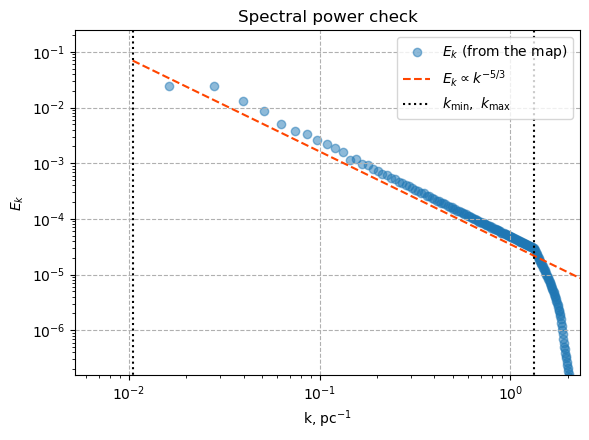

In [10]:
plt.figure(figsize=(6, 4.5))
plt.title("Spectral power check")

plt.scatter(k_centers, power, label=r'$E_k$ (from the map)', alpha=.5)
plt.loglog(k_values, 3.5e-5 * (k_values)**(-5/3), linestyle='dashed', label=r'$E_k\propto k^{-5/3}$', color='orangered')

plt.vlines([k_min, k_cube.max()], 1.1*min(power), 10*max(power), color='black', label=r'$k_\mathrm{min},~k_\mathrm{max}$', linestyles='dotted')

plt.xlabel(r'k, $\mathrm{pc}^{-1}$')
plt.xlim(0.5 * min_k, k_norm.max())

plt.ylabel(r'$E_k$')
plt.ylim(1e4*min(power), 10*max(power))

plt.legend(loc=1)

plt.grid(linestyle='dashed')

plt.tight_layout()
plt.show()

## Field lines

In [11]:
periodic_interpolator = PeriodicInterpolator(r_cube, b_cube_10)

In [12]:
M = 100
ds = dx / 5
n_steps = int(L / ds)  # n_steps

# calculate field lines
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, M, 3])
for i in range(M):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

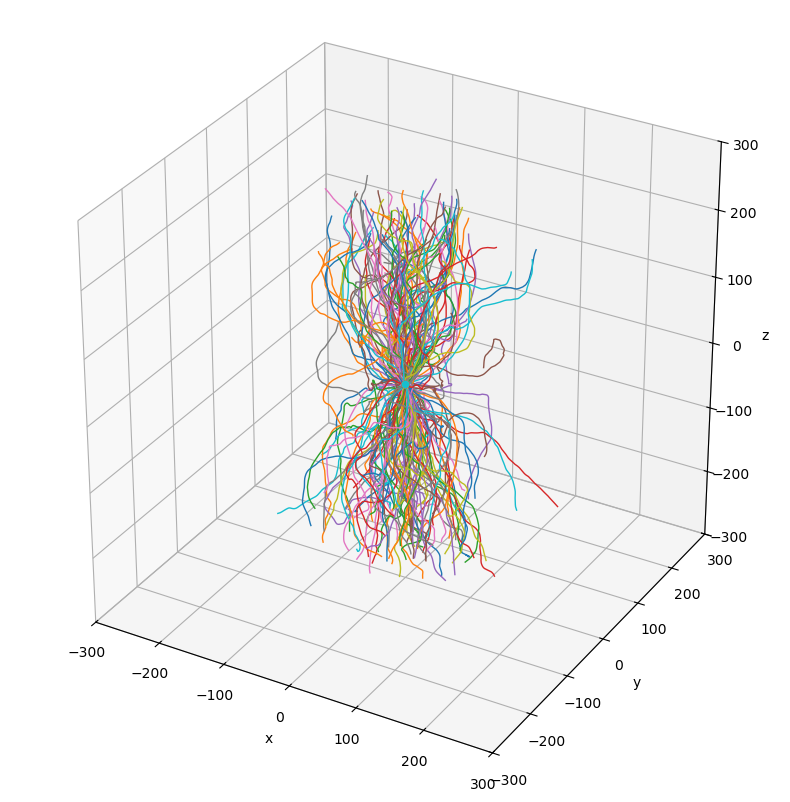

In [13]:
plot_field_lines(
    lines_from_zero,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

### **MF strength distribution** in space and along the MF line

**Relativistic magnetic moment conservation:**

$$ \mu_r = \dfrac{m\gamma^2v_\perp^2}{2B};\quad \dfrac{d\mu_r}{dt} = 0$$

*! it differs from a non-relativistic version $\mu=K_\perp/2B$ !*

**Energy conservation:**

$$ E = \gamma mc^2 = \sqrt{(pc)^2 + (mc^2)^2}$$

In the high-energy limit,

$$ E^2 = (pc)^2 = (\gamma m vc)^2 = \gamma^2 m^2 c^2 (v_\parallel^2 + v_\perp^2) = \gamma^2m^2c^4\cos^2\alpha + 2B\mu_r mc^2 $$
$$ \sin^2\alpha = \dfrac{2B\mu_r mc^2}{E^2} $$

In [14]:
from scipy.stats import norm

#### Analytical expression in 3D space

How is $B$ supposed to be distributed?

$$ \mathbf{B} = \dfrac{\mathbf{B}_0 + \eta\,\mathbf{\delta B}}{\sqrt{1 + \eta^2}} = \dfrac{1}{\sqrt{1 + \eta^2}}\mathbf{B}_0 + \dfrac{\eta}{\sqrt{1 + \eta^2}}\mathbf{\delta B}, $$

As $\mathbf{\delta B}\sim\mathcal{N}(\vec{0}, I_3/3),$ the total field $\mathbf{B}\sim\mathcal{N}\left(\dfrac{\mathbf{B}_0}{\sqrt{1 + \eta^2}}, \dfrac{\eta I_3}{3\sqrt{1+\eta^2}}\right)$.

This means that $B\sim\text{Noncentral}~\chi_3$ or **noncentral Maxwell distribution**.

In [15]:
mod_b_lines = (np.sum(fields**2, axis=-1))**(1/2)
mf_values = np.linspace(0, 2.5, 200)

ncol = mod_b_lines.shape[1]
cmap = plt.get_cmap('rainbow', lut=ncol)

In [16]:
from scipy.stats import ncx2

sigma = 1 / np.sqrt(3)
sigma_ef = sigma * eta / np.sqrt(1 + eta**2)

lam = (b0 / sigma_ef)**2

pdf = 2 * mf_values * ncx2(nc=lam, scale=sigma_ef**2, df=3).pdf(mf_values**2)

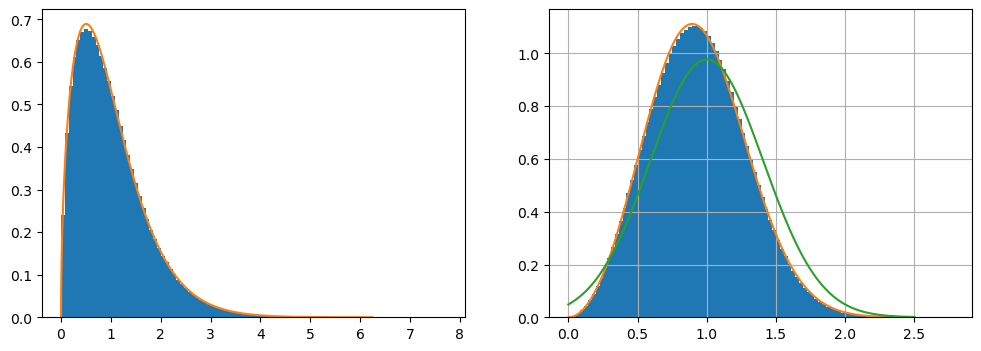

In [17]:
plt.figure(figsize=(12, 4))

plt.subplot(121)
plt.hist(np.sum(b_cube_10**2, axis=-1).ravel(), density=True, bins=100)
plt.plot(mf_values**2, ncx2(nc=lam, scale=sigma_ef**2, df=3).pdf(mf_values**2))

plt.subplot(122)
plt.hist(np.sqrt(np.sum(b_cube_10**2, axis=-1).ravel()), density=True, bins=100)
plt.plot(mf_values, pdf)
plt.plot(mf_values, norm(loc=1, scale=sigma_ef).pdf(mf_values))
plt.grid()

plt.show()

#### Distribution along the line

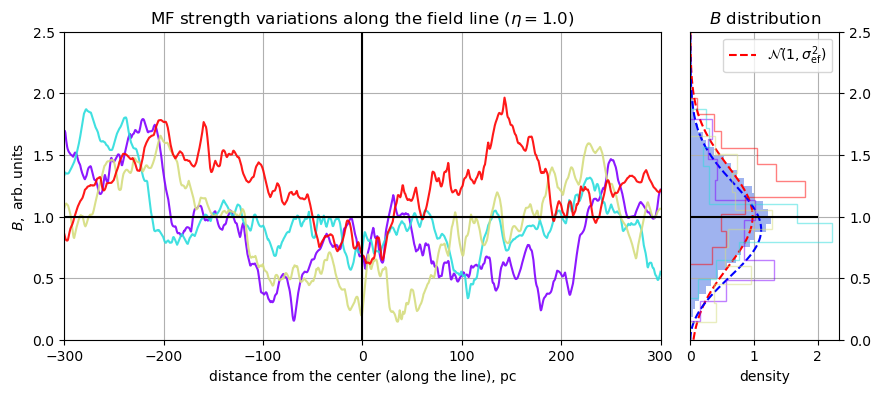

In [18]:

fig = plt.figure(figsize=(10, 4))
gs = plt.GridSpec(1, 2, fig, width_ratios=[4, 1], wspace=0.08)

ax = plt.subplot(gs[0, 0])
ax.set_title(r"MF strength variations along the field line ($\eta = $"f"{eta:.1f})")

for i in range(0, ncol, 33):
    ax.plot(np.arange(-n_steps, n_steps+1, 1) * ds, mod_b_lines[:, i], alpha=0.9, color=cmap(i/ncol))
    
ax.hlines([1.0], -ds*n_steps, ds*n_steps, color='black')
ax.vlines([0.0], mf_values[0], mf_values[-1], color='black')
    
ax.set_xlabel('distance from the center (along the line), pc')
ax.set_xlim(-ds*n_steps, ds*n_steps)
ax.set_ylabel(r"$B,$ arb. units")
ax.set_ylim(mf_values[0], mf_values[-1])
ax.grid()

# MF distribution
ax2 = plt.subplot(gs[0, 1])
ax2.set_title(r"$B$ distribution")
ax2.hist(mod_b_lines.ravel(), range=[mf_values[0], mf_values[-1]], bins=40,
         orientation='horizontal', density=True,
         alpha=0.5, color='royalblue')

ax2.plot(norm(loc=1, scale=sigma_ef).pdf(mf_values), mf_values, color='red', linestyle='dashed',
         label=r'$\mathcal{N}(1, \sigma_\mathrm{ef}^2)$')
ax2.plot(pdf, mf_values, color='blue', linestyle='dashed')

for i in range(0, ncol, 33):
    ax2.hist(mod_b_lines[:, i], alpha=0.5, color=cmap(i/ncol), histtype='step',
             orientation='horizontal', density=True)

ax2.hlines([1.0], 0, 2.0, color='black')

ax2.set_xlabel('density')
ax2.set_ylim(mf_values[0], mf_values[-1])
ax2.yaxis.tick_right()

ax2.legend(loc=1)

ax2.grid()

plt.show()

#### Power-spectrum along the line

In [19]:
k_s = 2 * np.pi * np.fft.rfftfreq(mod_b_lines.shape[0], d=ds)
mod_b_k = np.fft.rfft(mod_b_lines, axis=0, norm='forward')

In [20]:
print(f"Coordinate space: {mod_b_lines.shape}")
print(f"Momentum space: {mod_b_k.shape}")

Coordinate space: (1281, 100)
Momentum space: (641, 100)


In [21]:
print(k_s)
print(2*np.pi/(2*n_steps*ds))

[0.         0.0104638  0.0209276  0.0313914  0.0418552  0.052319
 0.0627828  0.0732466  0.08371041 0.09417421 0.10463801 0.11510181
 0.12556561 0.13602941 0.14649321 0.15695701 0.16742081 0.17788461
 0.18834841 0.19881221 0.20927601 0.21973981 0.23020361 0.24066742
 0.25113122 0.26159502 0.27205882 0.28252262 0.29298642 0.30345022
 0.31391402 0.32437782 0.33484162 0.34530542 0.35576922 0.36623302
 0.37669682 0.38716062 0.39762443 0.40808823 0.41855203 0.42901583
 0.43947963 0.44994343 0.46040723 0.47087103 0.48133483 0.49179863
 0.50226243 0.51272623 0.52319003 0.53365383 0.54411763 0.55458144
 0.56504524 0.57550904 0.58597284 0.59643664 0.60690044 0.61736424
 0.62782804 0.63829184 0.64875564 0.65921944 0.66968324 0.68014704
 0.69061084 0.70107464 0.71153845 0.72200225 0.73246605 0.74292985
 0.75339365 0.76385745 0.77432125 0.78478505 0.79524885 0.80571265
 0.81617645 0.82664025 0.83710405 0.84756785 0.85803165 0.86849546
 0.87895926 0.88942306 0.89988686 0.91035066 0.92081446 0.931278

In [22]:
2*np.pi / (0.1)

62.83185307179586

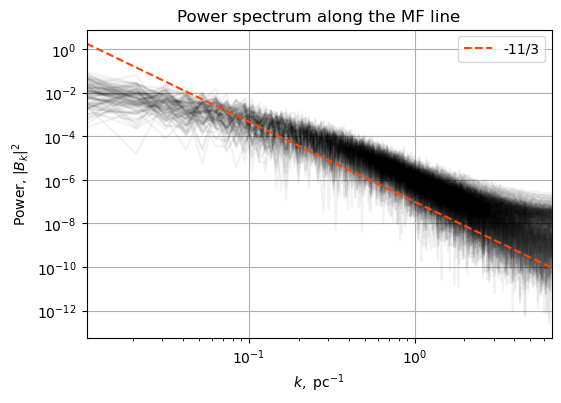

In [23]:
plt.figure(figsize=(6, 4))

plt.title("Power spectrum along the MF line")

plt.plot(k_s[k_s>0], np.abs(mod_b_k[k_s>0])**2, color='black', alpha=.05)
plt.plot(k_s[k_s>0], 1e-7 * k_s[k_s>0]**(-11/3), color='orangered', linestyle='dashed', label="-11/3")

plt.xscale('log')
plt.xlabel(r'$k,~\mathrm{pc}^{-1}$')
plt.xlim(2*np.pi/(2 * n_steps * ds), 2*np.pi/(2*ds))

plt.yscale('log')
plt.ylabel(r'Power, $|B_k|^2$')

plt.grid()
plt.legend(loc=1)

plt.show()

#### Typical magnetic field variation scale along the line

For this line, one can compute the average magnetic field variation scale $L_B \sim \dfrac{B}{\delta B / \delta s}$

In [24]:
grad_mod_b = (mod_b_lines[1:] - mod_b_lines[:-1]) / ds

b_avg = 0.5 * (mod_b_lines[1:] + mod_b_lines[:-1])

l_b = np.abs(b_avg / grad_mod_b).ravel()

l_b = l_b[l_b < 600]  # can't be > 600 pc

mean_l_b = np.average(l_b)

print(f"Average MF scale: {mean_l_b:.0f} pc")
print(f"Corresponding wavenumber {2*np.pi / mean_l_b:.3f} pc-1")

Average MF scale: 82 pc
Corresponding wavenumber 0.077 pc-1


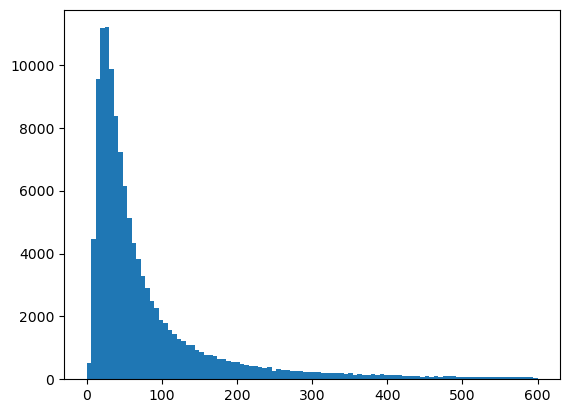

In [25]:
plt.hist(l_b, bins=100, range=(0, 600))
plt.show()

### Filtering

In [26]:
from scipy.ndimage import gaussian_filter1d

sigma = 300  # [pc], smoothing scale
lines_large = gaussian_filter1d(lines_from_zero, sigma=sigma, axis=0)

lines_large -= lines_large[n_steps, ...]

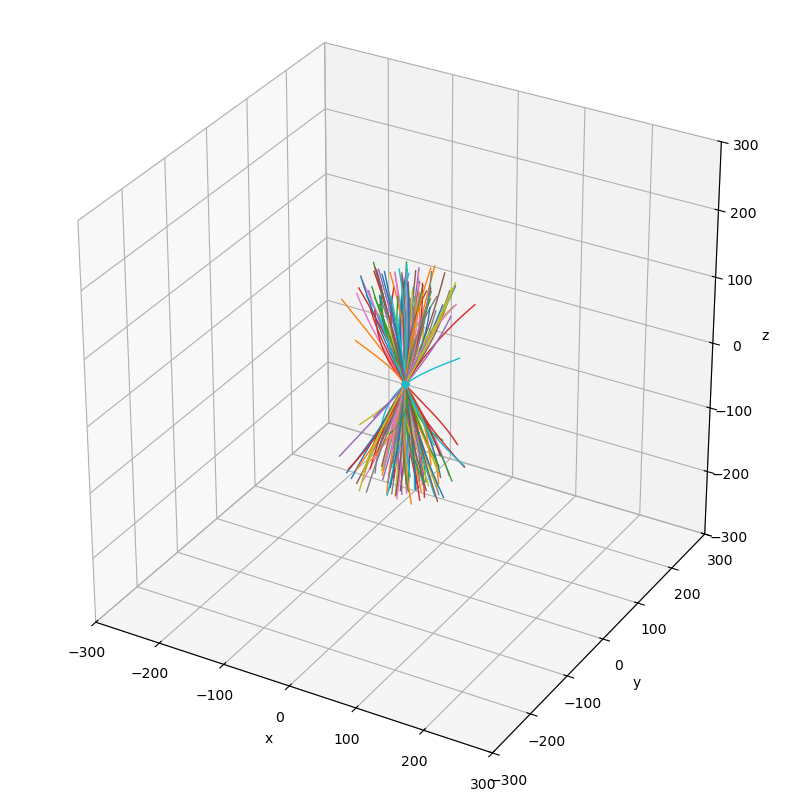

In [27]:
plot_field_lines(
    lines_large,
    n_lines=M,
    box_size=L
)
plt.tight_layout()
plt.show()

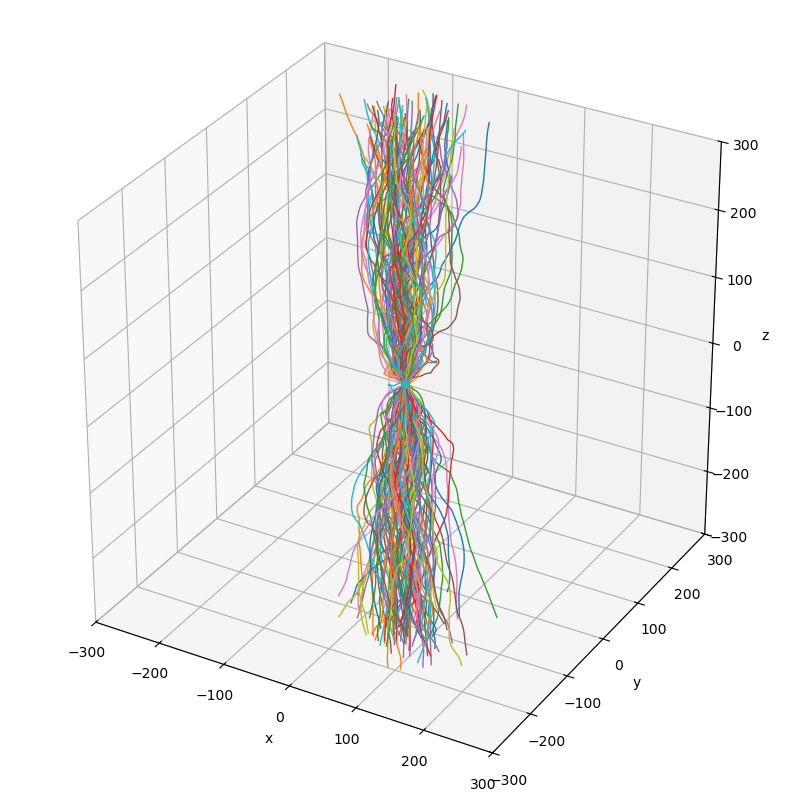

In [28]:
zero_vector = np.zeros_like(lines_large)

zero_vector[:, :, 2] =  (np.arange(-n_steps, n_steps+1, 1) * ds)[:, None]

plot_field_lines(
    (lines_from_zero - lines_large) + zero_vector,
    n_lines=M,
    box_size=L
)

# plot_field_lines(
#     lines_large,
#     n_lines=M,
#     box_size=L
# )
plt.tight_layout()
plt.show()

In [29]:
lines_from_zero.shape

(1281, 100, 3)

In [30]:
rho = lines_from_zero / np.linalg.norm(lines_from_zero, axis=-1, keepdims=True)
rho.shape

/tmp/ipykernel_18573/3722951336.py:1: RuntimeWarning: invalid value encountered in divide
  rho = lines_from_zero / np.linalg.norm(lines_from_zero, axis=-1, keepdims=True)


(1281, 100, 3)

## Observer view

Let observer direction be $\hat{n} = (\sin\phi, 0, \cos\phi)$.
In this case, we have to project the MF line onto the surface $\sigma: \vec{r}\cdot\hat{n} = 0.$

Projected vector is given by $\vec{r}_\sigma = \vec{r} - \hat{n}(\vec{r}\cdot\hat{n}) $

In [31]:
M = 1000
ds = dx / 5
n_steps = int(L / ds)  # n_steps

# calculate field lines
lines = integrate_lines(periodic_interpolator, M, n_steps, ds)

# calculate magnetic fields along the line
fields = np.zeros([2*n_steps + 1, M, 3])
for i in range(M):
    fields[:, i, :] = periodic_interpolator(lines[:, i])

# now shift the lines to 0
lines_from_zero = unwrap_lines(lines - lines[n_steps], 2 * L)

In [32]:
phi = np.linspace(0, 2 * np.pi, 36, endpoint=False)

n_vectors = np.array([np.sin(phi), np.zeros_like(phi), np.cos(phi)]).T
n_vectors.shape

(36, 3)

In [33]:
r_sigma = lines_from_zero[..., None, :]- n_vectors[None, None, ...] * np.sum(lines_from_zero[..., None, :] * n_vectors[None, None, ...], axis=-1, keepdims=True)

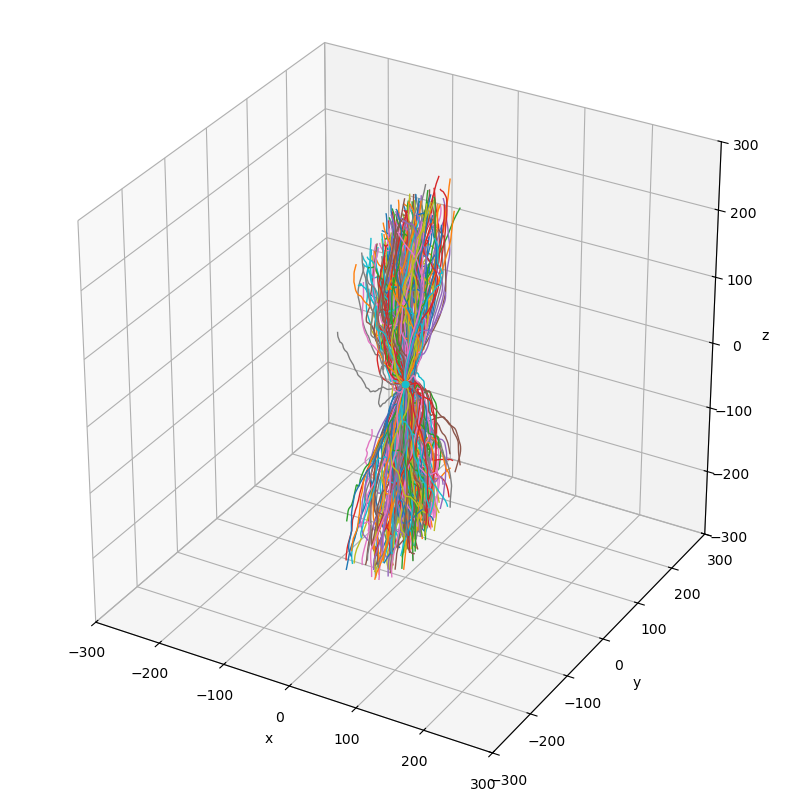

In [34]:
plot_field_lines(
    r_sigma[..., 9, :],
    n_lines=M//5,
    box_size=L
)

plt.tight_layout()
plt.show()

In [35]:
# create rotation matrix such that R n = z

In [36]:
ez = np.array([0, 0, 1]).T
a_nn = np.cross(n_vectors, ez)
a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation

theta = np.arccos(n_vectors @ ez)  # rotation angle

cross_a_r = np.cross(a, r_sigma)
dot_a_r = np.sum(a[None, None, ...] * r_sigma, axis=-1, keepdims=True)

/tmp/ipykernel_18573/2504275671.py:3: RuntimeWarning: invalid value encountered in divide
  a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation


In [37]:
rotated = r_sigma * np.cos(theta)[None, None, :, None] \
    + cross_a_r * np.sin(theta)[None, None, :, None] \
    + a[None, None, ...] * dot_a_r * (1 - np.cos(theta))[None, None, :, None]

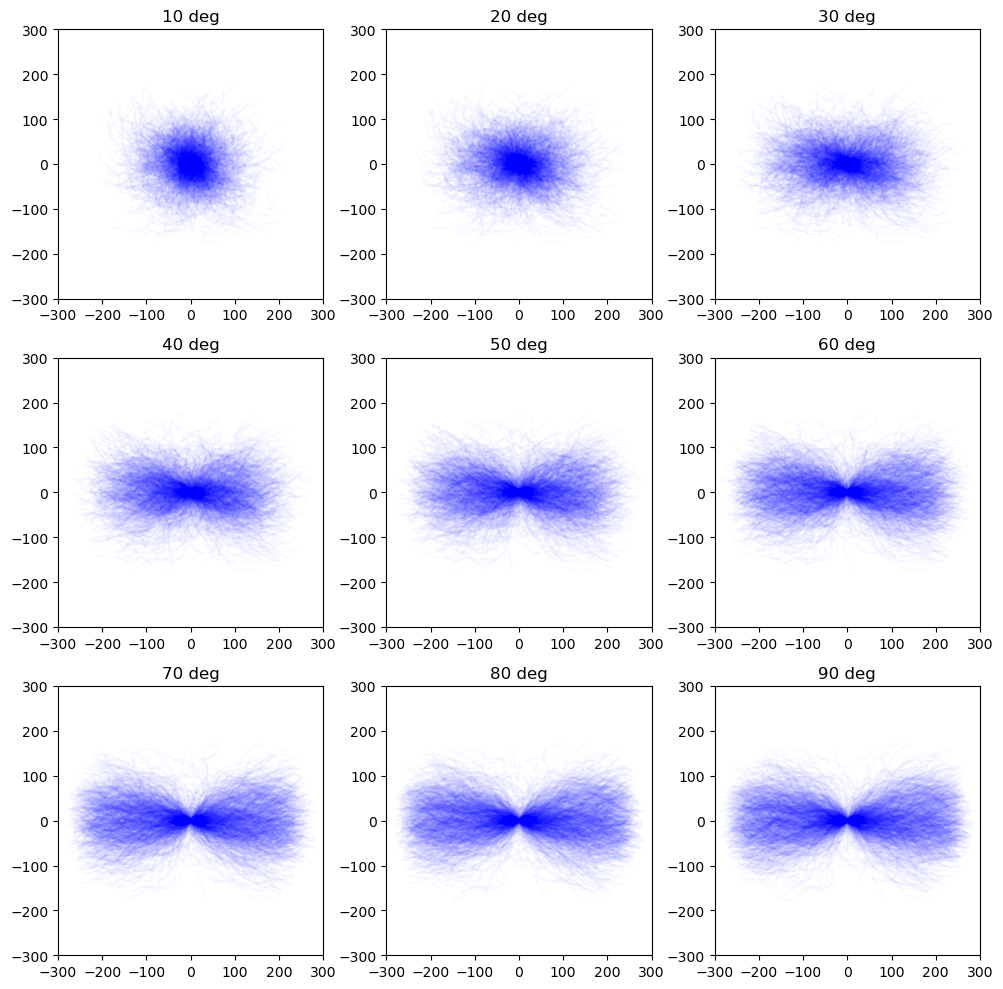

In [38]:
plt.figure(figsize=(10, 10))

for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.title(f"{np.rad2deg(phi[i]):.0f} deg")
    plt.xlim(-L, L)
    plt.ylim(-L, L)
    for m in range(0, M):
        x, y = rotated[::10, m, i, 0], rotated[::10, m, i, 1]
        plt.plot(x, y, color='blue', alpha=.02)

plt.tight_layout()
plt.show()

In [39]:
# Now we challenge the peanut geometry

In [40]:
import astropy.units as u
from astropy.coordinates import SkyCoord

peanut = SkyCoord(ra='02h15m6.50s', dec='+42d32m17.42', frame='icrs', distance=3 * u.kpc)
peanut_ang_length = 4.60 * u.deg
peanut_ang_width = 0.45 * u.deg
peanut_angle = 13.8 * u.deg  # to RA axis, almost aligned with b=cst

peanut_gal = peanut.galactic
peanut_length = np.abs(peanut_ang_length.to_value(u.rad) * peanut.distance * np.cos(peanut_gal.l)).to(u.pc)
peanut_width = (peanut_ang_width.to_value(u.rad) * peanut.distance).to(u.pc)
print(f"Peanut size is {peanut_length:.1f} x {peanut_width:.1f}")

Peanut size is 181.7 pc x 23.6 pc


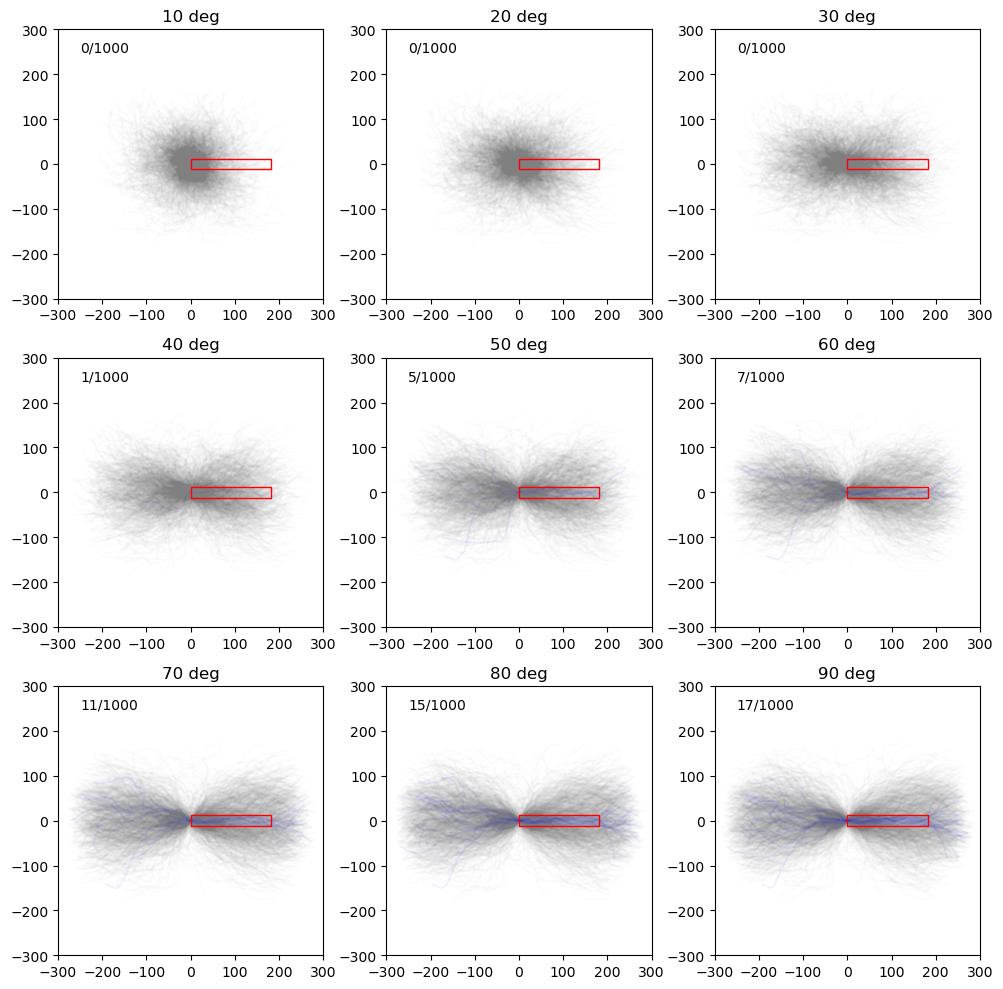

In [41]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(10, 10))

for i in range(1, 10):
    ax = plt.subplot(3, 3, i)
    ax.set_title(f"{np.rad2deg(phi[i]):.0f} deg")
    ax.set_xlim(-L, L)
    ax.set_ylim(-L, L)
    
    counter = 0
    
    for m in range(0, M):
        x, y = rotated[::10, m, i, 0], rotated[::10, m, i, 1]
        
        x_in = (x > 0) * (x < peanut_length.value)
        xy_in = np.abs(y[x_in]) < peanut_width.value / 2
        
        x_up = x > peanut_length.value  # peanut length
        
        color = 'gray'
        alpha = .02
        zorder = 0
        
        if np.prod(xy_in) > 0 and len(xy_in) > 0 and np.sum(x_up) > 0:
            color = 'blue'
            alpha = .05
            zorder = 9
            counter += 1
        
        ax.plot(x, y, color=color, alpha=alpha, zorder=zorder)
    
    rect = Rectangle((0, -peanut_width.value/2), width=peanut_length.value, height=peanut_width.value,
                     facecolor='none', edgecolor='red', linewidth=1, zorder=10)
    ax.add_patch(rect)
    ax.text(-250, 250, f"{counter}/{M}")

plt.tight_layout()
plt.show()